# Reconstrucción de la ruta de vuelo tras un fallo de GPS

## Parcial 2 — Métodos Numéricos · Montería Drone Delivery (MDD)

**Autores:** Santiago Anaya Ramos y Andrés David Cuello Acosta
**Métodos analizados:** Mínimos cuadrados (Gauss) · Interpolación de Lagrange

---

### Resumen

Durante un vuelo de prueba sobre el río Sinú, el GPS del dron sufrió una
interferencia electromagnética y **perdió la señal en el segundo 5**. Solo
quedaron almacenadas 10 lecturas de altitud $y$ (metros) frente al tiempo $x$
(segundos).

Este informe reconstruye la altitud del instante perdido por dos caminos
distintos y decide cuál es técnicamente más seguro:

1. **Mínimos cuadrados**, que ajusta una curva de *tendencia global* a las 10
   lecturas y se evalúa con el coeficiente $R^2$.
2. **Interpolación de Lagrange**, que construye el polinomio que pasa
   *exactamente* por los vecinos del hueco.

Los parámetros personales $D$ y $E$ (últimos dígitos de las cédulas) definen dos
celdas de la tabla, de modo que la base de telemetría es única para esta pareja.
El documento es ejecutable: al cambiar $D$ y $E$ se recalculan ecuaciones,
tablas, gráficas y conclusiones.

### Contenido

1. Escenario y tabla de vuelo
2. Regresión por mínimos cuadrados
3. Interpolación de Lagrange
4. Informe de diagnóstico
5. Sustentación: ráfaga de viento en el segundo 4
6. Conclusiones
7. Anexo — código de los algoritmos


In [1]:
%pip -q install sympy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import inspect
import re

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display, Math, Markdown

x = sp.symbols("x")

pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

### Ayudas de presentación *(no forma parte del informe exportado)*

Convierten expresiones y números en LaTeX legible.

In [3]:
def a_latex(expresion, decimales=6):
    """Expresión de SymPy -> texto LaTeX legible.

    decimales=None deja la expresión tal cual (forma general, sin redondear).
    """
    if decimales is not None:
        expresion = sp.N(expresion, decimales)

    texto = sp.latex(expresion, order="none")

    # SymPy escribe "9.0 x^{2}"; se lee mejor como "9 x^{2}".
    return re.sub(r"(\d)\.0(?!\d)", r"\1", texto)


def num(valor, decimales=6):
    """Número -> texto para LaTeX, con notación científica si es muy pequeño."""
    valor = float(valor)

    if valor != 0 and abs(valor) < 1e-4:
        base, exponente = f"{valor:.4e}".split("e")
        return rf"{base} \times 10^{{{int(exponente)}}}"

    # Quitamos los ceros sobrantes: 19.000000 se lee mejor como 19.
    return f"{valor:.{decimales}f}".rstrip("0").rstrip(".")

# 1. Escenario y tabla de vuelo

El dron almacenó 10 lecturas de altitud durante un vuelo de 10 segundos, desde el
despegue hasta el aterrizaje. En el **segundo 5** no hay dato: el GPS perdió la
señal por la interferencia.

Dos celdas de la tabla dependen de los parámetros personales:

$$
y(3) = 10 + D \qquad y(6) = 22 + E
$$

donde $D$ y $E$ son los últimos dígitos de las cédulas de los dos estudiantes
(si el dígito es 0 se usa 9). El terreno impone además un obstáculo: **árboles de
15 m**, que fija el margen de seguridad del vuelo.

### 1.1 Parámetros personales y tabla de telemetría


In [4]:
# --- Parámetros del caso analizado --------------------------------------
# Cambia D y E y vuelve a ejecutar el documento completo
# (Kernel -> Restart & Run All) para regenerar el informe con otros datos.
D = 9                 # último dígito de la cédula del estudiante 1
E = 6                 # último dígito de la cédula del estudiante 2
t_falla = 5.0         # segundo en que se perdió la señal del GPS
altura_arboles = 15   # obstáculo del terreno (metros)

telemetria = pd.DataFrame({
    "x (s)": [0, 1, 2, 3, 4, 6, 7, 8, 9, 10],
    "y (m)": [0, 12, 18, 10 + D, 25, 22 + E, 32, 30, 15, 0],
    "Origen": ["Despegue", "", "", f"10 + D = 10 + {D}", "",
               f"22 + E = 22 + {E}", "", "", "", "Aterrizaje"],
})

tx = telemetria["x (s)"].to_numpy(float)
ty = telemetria["y (m)"].to_numpy(float)

display(Math(
    rf"D = {D} \qquad E = {E} \qquad "
    rf"x_{{\text{{falla}}}} = {num(t_falla, 0)} \qquad "
    rf"h_{{\text{{árboles}}}} = {altura_arboles}\ \text{{m}}"
))
display(telemetria)

<IPython.core.display.Math object>

,x (s),y (m),Origen
0,0,0,Despegue
1,1,12,
2,2,18,
3,3,19,10 + D = 10 + 9
4,4,25,
5,6,28,22 + E = 22 + 6
6,7,32,
7,8,30,
8,9,15,
9,10,0,Aterrizaje


### 1.2 Localización gráfica del hueco

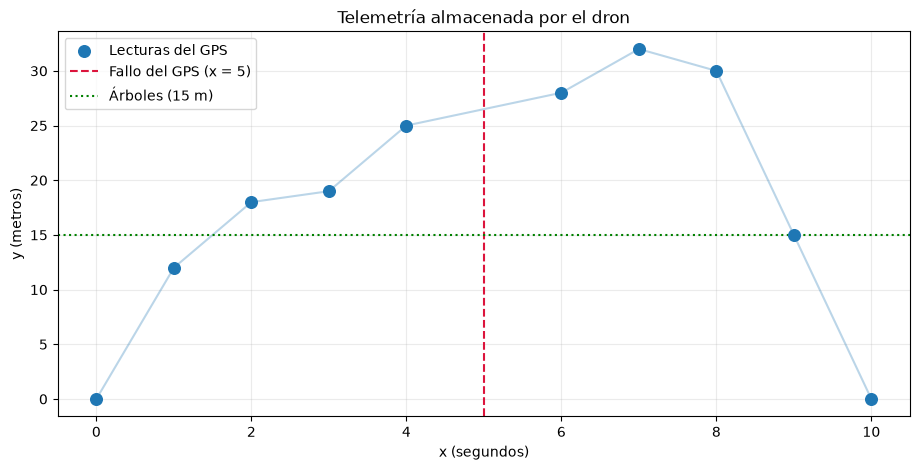

In [5]:
plt.figure()
plt.scatter(tx, ty, s=70, zorder=5, label="Lecturas del GPS")
plt.plot(tx, ty, alpha=0.3)
plt.axvline(t_falla, linestyle="--", color="crimson",
            label=f"Fallo del GPS (x = {t_falla:.0f})")
plt.axhline(altura_arboles, linestyle=":", color="green",
            label=f"Árboles ({altura_arboles} m)")
plt.title("Telemetría almacenada por el dron")
plt.xlabel("x (segundos)")
plt.ylabel("y (metros)")
plt.legend()
plt.show()

# 2. Regresión por mínimos cuadrados

El método de **mínimos cuadrados**, heredado de Gauss, busca el polinomio $p(x)$
que minimiza la suma de los residuos al cuadrado sobre **todas** las lecturas:

$$
S = \sum_{i=1}^{n}\bigl(y_i - p(x_i)\bigr)^2 \longrightarrow \min
$$

Derivando $S$ respecto de cada coeficiente e igualando a cero se obtienen las
**ecuaciones normales**. Para el ajuste cuadrático $p(x) = ax^2 + bx + c$ son el
sistema lineal

$$
\begin{aligned}
a\sum x_i^4 + b\sum x_i^3 + c\sum x_i^2 &= \sum x_i^2 y_i \\
a\sum x_i^3 + b\sum x_i^2 + c\sum x_i \;\; &= \sum x_i y_i \\
a\sum x_i^2 + b\sum x_i \;\; + c\,n \;\;\;&= \sum y_i
\end{aligned}
$$

La calidad del ajuste se mide con el **coeficiente de determinación**

$$
R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
    = 1 - \frac{\sum (y_i - p(x_i))^2}{\sum (y_i - \bar{y})^2}
$$

$R^2 = 1$ significa que la curva pasa por todos los puntos; $R^2 = 0$, que no
explica nada más allá de la media de los datos.

### 2.1 Ajuste cuadrático (grado 2) y cúbico (grado 3)


In [6]:
def minimos_cuadrados(xs, ys, grado):
    """Ajuste polinómico por mínimos cuadrados.

    Devuelve (coeficientes de mayor a menor grado, R^2).
    """
    coef = np.polyfit(xs, ys, grado)
    ss_res = float(np.sum((ys - np.polyval(coef, xs)) ** 2))
    ss_tot = float(np.sum((ys - ys.mean()) ** 2))
    return coef, 1 - ss_res / ss_tot


def polinomio_expr(coef):
    """Coeficientes de numpy -> expresión de SymPy en la variable x."""
    grado = len(coef) - 1
    return sum(sp.Float(float(c)) * x ** (grado - i) for i, c in enumerate(coef))


ajustes = {}
for grado in (2, 3):
    coef, r2 = minimos_cuadrados(tx, ty, grado)
    ajustes[grado] = (coef, r2)

    display(Markdown(f"**Ajuste de grado {grado}**"))
    display(Math(r"p_{%d}(x) = %s" % (grado, a_latex(polinomio_expr(coef), 6))))
    display(Math(rf"R^2 = {num(r2)}"))

**Ajuste de grado 2**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Ajuste de grado 3**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 2.2 Coeficientes del ajuste cuadrático

In [7]:
# Sumatorias que alimentan las ecuaciones normales del ajuste cuadrático.
n = len(tx)
sumatorias = pd.DataFrame([{
    "n": n,
    "Σx": tx.sum(), "Σx²": (tx**2).sum(), "Σx³": (tx**3).sum(), "Σx⁴": (tx**4).sum(),
    "Σy": ty.sum(), "Σxy": (tx*ty).sum(), "Σx²y": (tx**2*ty).sum(),
}])
display(sumatorias)

a2, b2, c2 = ajustes[2][0]
r2_cuad = ajustes[2][1]

display(Math(rf"a = {num(a2)} \qquad b = {num(b2)} \qquad c = {num(c2)}"))
display(Math(
    rf"y = {num(a2)}\,x^2 + ({num(b2)})\,x + ({num(c2)})"
    rf" \qquad R^2 = {num(r2_cuad)}"
))

,n,Σx,Σx²,Σx³,Σx⁴,Σy,Σxy,Σx²y
0,10,50.0,360.0,2900.0,24708.0,179.0,972.0,6366.0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 2.3 Curvas de tendencia frente a los datos

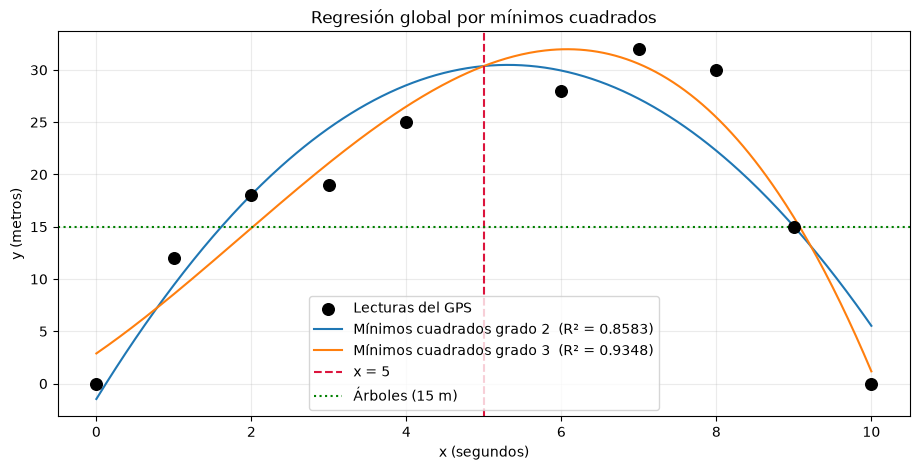

,x (s),y observado,p₂(x),residuo grado 2,p₃(x),residuo grado 3
0,0.0,0.0,-1.4717,1.4717,2.8850,-2.8850
1,1.0,12.0,9.4316,2.5684,8.5602,3.4398
2,2.0,18.0,18.0674,-0.0674,14.8725,3.1275
3,3.0,19.0,24.4358,-5.4358,21.0957,-2.0957
4,4.0,25.0,28.5369,-3.5369,26.5038,-1.5038
5,6.0,28.0,29.9369,-1.9369,31.9700,-3.9700
6,7.0,32.0,27.2358,4.7642,30.5759,1.4241
7,8.0,30.0,22.2674,7.7326,25.4623,4.5377
8,9.0,15.0,15.0316,-0.0316,15.9029,-0.9029
9,10.0,0.0,5.5283,-5.5283,1.1717,-1.1717


In [8]:
malla = np.linspace(tx.min(), tx.max(), 400)

plt.figure()
plt.scatter(tx, ty, s=70, zorder=5, color="black", label="Lecturas del GPS")
for grado, (coef, r2) in ajustes.items():
    plt.plot(malla, np.polyval(coef, malla),
             label=f"Mínimos cuadrados grado {grado}  (R² = {r2:.4f})")
plt.axvline(t_falla, linestyle="--", color="crimson", label=f"x = {t_falla:.0f}")
plt.axhline(altura_arboles, linestyle=":", color="green",
            label=f"Árboles ({altura_arboles} m)")
plt.title("Regresión global por mínimos cuadrados")
plt.xlabel("x (segundos)")
plt.ylabel("y (metros)")
plt.legend()
plt.show()

residuos = pd.DataFrame({
    "x (s)": tx,
    "y observado": ty,
    "p₂(x)": np.polyval(ajustes[2][0], tx),
    "residuo grado 2": ty - np.polyval(ajustes[2][0], tx),
    "p₃(x)": np.polyval(ajustes[3][0], tx),
    "residuo grado 3": ty - np.polyval(ajustes[3][0], tx),
})
display(residuos.round(4))

# 3. Interpolación de Lagrange

La regresión describe la tendencia general, pero **no pasa por los puntos**. Para
recuperar la altitud del segundo perdido se usa un polinomio que sí pasa
exactamente por los datos vecinos: el **polinomio interpolador de Lagrange**

$$
P(x) = \sum_{i=0}^{n} y_i\,L_i(x),
\qquad
L_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}
$$

Cada base $L_i$ vale $1$ en su propio nodo $x_i$ y $0$ en los demás, de modo que
$P(x_i) = y_i$ para todos los nodos utilizados.

Para el segundo 5 se toman los **cuatro vecinos disponibles**, $x = 3, 4, 6, 7$,
que producen un polinomio de grado 3 centrado en el hueco.

### 3.1 Construcción del polinomio interpolador


In [9]:
def lagrange(nodos_x, nodos_y):
    """Polinomio interpolador de Lagrange como expresión de SymPy."""
    P = 0
    for i, (xi, yi) in enumerate(zip(nodos_x, nodos_y)):
        P += sp.Float(yi) * base_lagrange(nodos_x, i)
    return sp.expand(P)


def base_lagrange(nodos_x, i):
    """Base L_i(x) sin expandir, para mostrar el desarrollo paso a paso."""
    Li = sp.Integer(1)
    xi = nodos_x[i]
    for j, xj in enumerate(nodos_x):
        if i != j:
            Li *= (x - sp.Float(xj)) / sp.Float(xi - xj)
    return Li


vecinos = [3.0, 4.0, 6.0, 7.0]
vecinos_y = [float(ty[list(tx).index(v)]) for v in vecinos]

display(Markdown("**Nodos utilizados (vecinos del segundo con fallo)**"))
display(pd.DataFrame({"x (s)": vecinos, "y (m)": vecinos_y}))

for i, yi in enumerate(vecinos_y):
    display(Math(
        rf"L_{{{i}}}(x) = {a_latex(base_lagrange(vecinos, i), None)}"
        rf" \qquad y_{{{i}}} = {num(yi)}"
    ))

**Nodos utilizados (vecinos del segundo con fallo)**

,x (s),y (m)
0,3.0,19.0
1,4.0,25.0
2,6.0,28.0
3,7.0,32.0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3.2 Evaluación en el segundo del fallo

In [10]:
P_lagrange = lagrange(vecinos, vecinos_y)

# Verificación interna: el interpolador debe reproducir exactamente cada nodo.
for xi, yi in zip(vecinos, vecinos_y):
    assert abs(float(P_lagrange.subs(x, xi)) - yi) < 1e-9

display(Markdown("**Polinomio interpolador**"))
display(Math(r"P(x) = " + a_latex(P_lagrange, 6)))

terminos = [yi * float(base_lagrange(vecinos, i).subs(x, t_falla))
            for i, yi in enumerate(vecinos_y)]

display(Markdown(f"**Sustitución en x = {t_falla:.0f}**"))
display(Math(
    r"P(%s) = " % num(t_falla, 0)
    + " + ".join(rf"({num(yi)})\,L_{{{i}}}({num(t_falla, 0)})"
                 for i, yi in enumerate(vecinos_y))
))
display(Math(
    r"P(%s) = " % num(t_falla, 0)
    + " + ".join(f"({num(t)})" for t in terminos)
))

y_lagrange = float(P_lagrange.subs(x, t_falla))
display(Math(rf"\boxed{{P({num(t_falla, 0)}) = {num(y_lagrange)}\ \text{{m}}}}"))

**Polinomio interpolador**

<IPython.core.display.Math object>

**Sustitución en x = 5**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3.3 Interpolador local frente a la regresión global

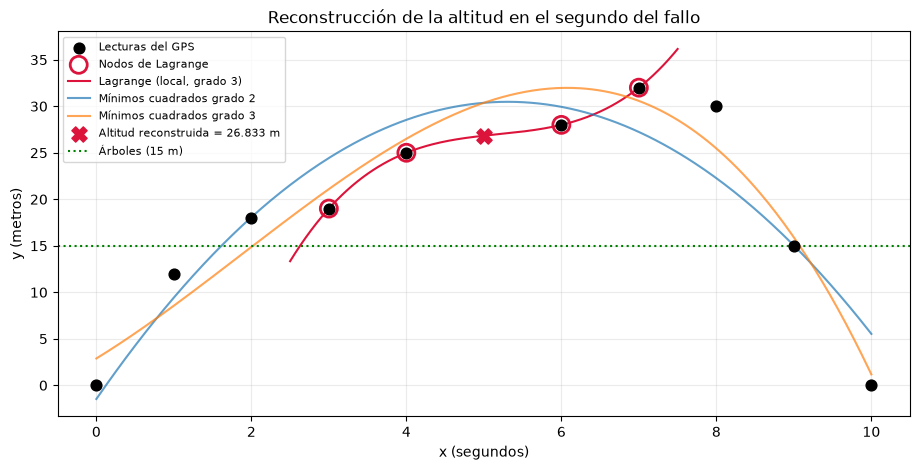

In [11]:
malla_local = np.linspace(min(vecinos) - 0.5, max(vecinos) + 0.5, 300)
P_num = sp.lambdify(x, P_lagrange, "numpy")

plt.figure()
plt.scatter(tx, ty, s=60, color="black", zorder=5, label="Lecturas del GPS")
plt.scatter(vecinos, vecinos_y, s=150, facecolors="none", edgecolors="crimson",
            linewidths=2, zorder=6, label="Nodos de Lagrange")
plt.plot(malla_local, P_num(malla_local), color="crimson",
         label="Lagrange (local, grado 3)")
for grado, (coef, r2) in ajustes.items():
    plt.plot(malla, np.polyval(coef, malla), alpha=0.7,
             label=f"Mínimos cuadrados grado {grado}")
plt.scatter([t_falla], [y_lagrange], s=120, color="crimson", marker="X", zorder=7,
            label=f"Altitud reconstruida = {y_lagrange:.3f} m")
plt.axhline(altura_arboles, linestyle=":", color="green",
            label=f"Árboles ({altura_arboles} m)")
plt.title("Reconstrucción de la altitud en el segundo del fallo")
plt.xlabel("x (segundos)")
plt.ylabel("y (metros)")
plt.legend(fontsize=8)
plt.show()

# 4. Informe de diagnóstico

Se comparan las estimaciones de la altitud en el segundo 5 y se contrastan con el
obstáculo del terreno. El margen de seguridad es

$$
\text{margen} = y(5) - h_{\text{árboles}}
$$


In [12]:
y_reg2 = float(np.polyval(ajustes[2][0], t_falla))
y_reg3 = float(np.polyval(ajustes[3][0], t_falla))

diagnostico = pd.DataFrame([
    {"Método": "Mínimos cuadrados grado 2", "y(5) [m]": y_reg2,
     "R²": ajustes[2][1], "Margen sobre árboles [m]": y_reg2 - altura_arboles},
    {"Método": "Mínimos cuadrados grado 3", "y(5) [m]": y_reg3,
     "R²": ajustes[3][1], "Margen sobre árboles [m]": y_reg3 - altura_arboles},
    {"Método": "Lagrange (x = 3, 4, 6, 7)", "y(5) [m]": y_lagrange,
     "R²": 1.0, "Margen sobre árboles [m]": y_lagrange - altura_arboles},
])
display(diagnostico.round(6))

display(Math(
    rf"\Delta_2 = |P(5) - p_2(5)| = |{num(y_lagrange)} - {num(y_reg2)}|"
    rf" = {num(abs(y_lagrange - y_reg2))}\ \text{{m}}"
))
display(Math(
    rf"\Delta_3 = |P(5) - p_3(5)| = |{num(y_lagrange)} - {num(y_reg3)}|"
    rf" = {num(abs(y_lagrange - y_reg3))}\ \text{{m}}"
))

for etiqueta, valor in (("Lagrange", y_lagrange),
                        ("Mínimos cuadrados grado 2", y_reg2),
                        ("Mínimos cuadrados grado 3", y_reg3)):
    estado = "por encima de" if valor > altura_arboles else "POR DEBAJO DE"
    display(Markdown(
        f"- **{etiqueta}**: {valor:.3f} m — {estado} los árboles de "
        f"{altura_arboles} m (margen {valor - altura_arboles:+.3f} m)."
    ))

,Método,y(5) [m],R²,Margen sobre árboles [m]
0,Mínimos cuadrados grado 2,30.370588,0.858288,15.370588
1,Mínimos cuadrados grado 3,30.370588,0.934772,15.370588
2,"Lagrange (x = 3, 4, 6, 7)",26.833333,1.000000,11.833333


<IPython.core.display.Math object>

<IPython.core.display.Math object>

- **Lagrange**: 26.833 m — por encima de los árboles de 15 m (margen +11.833 m).

- **Mínimos cuadrados grado 2**: 30.371 m — por encima de los árboles de 15 m (margen +15.371 m).

- **Mínimos cuadrados grado 3**: 30.371 m — por encima de los árboles de 15 m (margen +15.371 m).

### 4.1 Criterio técnico: ¿qué método es más seguro?

**Para reconstruir la altitud del segundo 5, el método seguro es la interpolación
de Lagrange**, por tres razones:

1. **Pasa por los datos.** Lagrange reproduce exactamente las lecturas vecinas
   ($P(x_i) = y_i$), mientras que la regresión suaviza la trayectoria y deja
   residuos en todos los puntos. Frente a un obstáculo de 15 m, un error de
   varios metros por suavizado no es aceptable.
2. **Es local.** El hueco está en mitad del vuelo, rodeado de cuatro lecturas
   fiables y próximas: el interpolador solo usa esa vecindad y no arrastra la
   forma del despegue ni del aterrizaje.
3. **La regresión responde a otra pregunta.** Los mínimos cuadrados describen la
   *tendencia global* del perfil de vuelo —útil para planear la ruta o detectar
   deriva sistemática—, pero no pretenden pasar por ningún punto concreto.

**Nota sobre la coincidencia $p_2(5) = p_3(5)$.** Los tiempos registrados son
simétricos respecto a $x = 5$ (0…4 y 6…10), y en una malla simétrica la corrección
cúbica del ajuste es una función impar centrada en 5: se anula justo en ese punto.
Por eso ambos ajustes dan el mismo valor en el segundo del fallo aunque su $R^2$
sea distinto.

**Límites del criterio.** Lagrange solo es seguro *dentro* del intervalo de sus
nodos: fuera de $[3, 7]$ el polinomio de grado 3 oscila y extrapola mal. Si los
datos tuvieran ruido de medición, o si hubiera que decidir sobre la ruta
completa, la referencia adecuada sería la curva de mínimos cuadrados; para tapar
un hueco puntual entre datos confiables, Lagrange.


# 5. Sustentación: ráfaga de viento en el segundo 4

Variación pedida en la sustentación en vivo: una ráfaga de viento modifica en un
**50 %** la altitud registrada en el segundo 4. Se recalcula todo el análisis con
$y(4)$ aumentado y reducido a la mitad, y se observa el efecto sobre $R^2$ y
sobre la estabilidad de la ecuación.


In [13]:
def escenario(factor):
    """Recalcula ajustes y Lagrange con y(4) multiplicado por `factor`."""
    ys = ty.copy()
    i4 = list(tx).index(4.0)
    ys[i4] = ty[i4] * factor

    fila = {"Escenario": f"y(4) × {factor:.1f} = {ys[i4]:.2f} m"}
    for grado in (2, 3):
        coef, r2 = minimos_cuadrados(tx, ys, grado)
        fila[f"R² grado {grado}"] = r2
        fila[f"p{grado}(5) [m]"] = float(np.polyval(coef, t_falla))

    ys_vecinos = [float(ys[list(tx).index(v)]) for v in vecinos]
    fila["Lagrange(5) [m]"] = float(lagrange(vecinos, ys_vecinos).subs(x, t_falla))
    return fila, ys


escenarios = pd.DataFrame([escenario(f)[0] for f in (1.0, 1.5, 0.5)])
display(escenarios.round(6))

,Escenario,R² grado 2,p2(5) [m],R² grado 3,p3(5) [m],Lagrange(5) [m]
0,y(4) × 1.0 = 25.00 m,0.858288,30.370588,0.934772,30.370588,26.833333
1,y(4) × 1.5 = 37.50 m,0.868407,33.458824,0.899575,33.458824,35.166667
2,y(4) × 0.5 = 12.50 m,0.673333,27.282353,0.802858,27.282353,18.500000


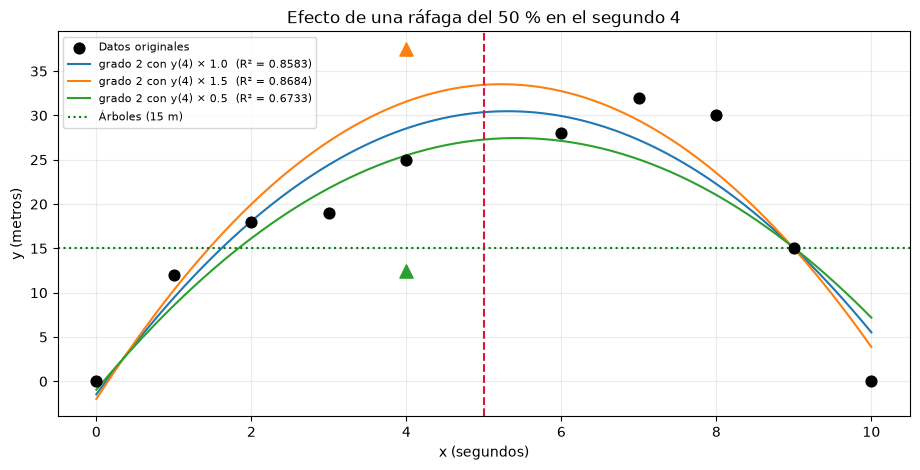

In [14]:
plt.figure()
plt.scatter(tx, ty, s=60, color="black", zorder=5, label="Datos originales")
for factor, color in ((1.0, "tab:blue"), (1.5, "tab:orange"), (0.5, "tab:green")):
    _, ys = escenario(factor)
    coef, r2 = minimos_cuadrados(tx, ys, 2)
    plt.plot(malla, np.polyval(coef, malla), color=color,
             label=f"grado 2 con y(4) × {factor:.1f}  (R² = {r2:.4f})")
    if factor != 1.0:
        plt.scatter([4], [ys[list(tx).index(4.0)]], color=color,
                    marker="^", s=90, zorder=6)
plt.axvline(t_falla, linestyle="--", color="crimson")
plt.axhline(altura_arboles, linestyle=":", color="green",
            label=f"Árboles ({altura_arboles} m)")
plt.title("Efecto de una ráfaga del 50 % en el segundo 4")
plt.xlabel("x (segundos)")
plt.ylabel("y (metros)")
plt.legend(fontsize=8)
plt.show()

**Lectura del resultado.** Alterar un solo dato cambia dos cosas de distinta
gravedad:

- **$R^2$ baja** cuando el punto movido se aleja de la tendencia: ese dato deja de
  ser explicado por la curva y engorda $SS_{\text{res}}$. La caída de $R^2$ es,
  por tanto, un **detector de dato anómalo**, no una señal de que el método falle.
- **Los coeficientes se mueven poco.** Mínimos cuadrados reparte el error entre
  las 10 lecturas, así que un punto malo desplaza la curva ligeramente: el ajuste
  es **estable frente al ruido**.
- **Lagrange sí se desplaza de golpe** cuando el nodo alterado es uno de los
  suyos, porque está obligado a pasar por él. Esa es la contrapartida de su
  exactitud: interpola también el error.

Conclusión operativa: con datos limpios se interpola (Lagrange); con datos
sospechosos de ruido se ajusta (mínimos cuadrados) y se vigila $R^2$.


# 6. Conclusiones

| Criterio | Mínimos cuadrados | Interpolación de Lagrange |
| --- | --- | --- |
| Qué produce | curva de **tendencia** global | curva que **pasa por los nodos** |
| Usa | todas las lecturas | solo los vecinos del hueco |
| Pasa por los datos | no | sí, exactamente |
| Frente al ruido | lo promedia (estable) | lo reproduce (sensible) |
| Fuera del rango | extrapola de forma razonable | oscila; no debe extrapolarse |
| Indicador de calidad | $R^2$ | exacto en los nodos por construcción |

1. Los dos métodos responden a preguntas distintas: la regresión describe **cómo
   voló el dron en general**; Lagrange responde **qué altitud tenía en el segundo
   5**. Tratarlos como competidores es el error conceptual del problema.
2. Para el hueco del GPS, rodeado de lecturas fiables, la reconstrucción segura es
   la de Lagrange; la diferencia frente a la regresión cuantifica cuánto suaviza
   el ajuste global.
3. El obstáculo de 15 m obliga a decidir con el valor más fiel al dato real: un
   suavizado que sobrestime la altura recortaría un margen de seguridad que en el
   terreno no existe.
4. $R^2$ mide ajuste, no seguridad. Un $R^2$ alto con una curva que no pasa por
   ningún punto sigue sin servir para decidir la altura en un instante concreto.


# 7. Anexo — código de los algoritmos

Implementación de los dos métodos tal como fueron ejecutados en este documento.


In [15]:
# inspect.getsource lee el código fuente real de cada función, así el anexo
# nunca queda desactualizado respecto a lo que se ejecutó.
for funcion in (minimos_cuadrados, base_lagrange, lagrange):
    try:
        display(Markdown("```python\n" + inspect.getsource(funcion) + "```"))
    except OSError:
        display(Markdown(f"*(no se pudo leer el código de `{funcion.__name__}`)*"))

```python
def minimos_cuadrados(xs, ys, grado):
    """Ajuste polinómico por mínimos cuadrados.

    Devuelve (coeficientes de mayor a menor grado, R^2).
    """
    coef = np.polyfit(xs, ys, grado)
    ss_res = float(np.sum((ys - np.polyval(coef, xs)) ** 2))
    ss_tot = float(np.sum((ys - ys.mean()) ** 2))
    return coef, 1 - ss_res / ss_tot
```

```python
def base_lagrange(nodos_x, i):
    """Base L_i(x) sin expandir, para mostrar el desarrollo paso a paso."""
    Li = sp.Integer(1)
    xi = nodos_x[i]
    for j, xj in enumerate(nodos_x):
        if i != j:
            Li *= (x - sp.Float(xj)) / sp.Float(xi - xj)
    return Li
```

```python
def lagrange(nodos_x, nodos_y):
    """Polinomio interpolador de Lagrange como expresión de SymPy."""
    P = 0
    for i, (xi, yi) in enumerate(zip(nodos_x, nodos_y)):
        P += sp.Float(yi) * base_lagrange(nodos_x, i)
    return sp.expand(P)
```